In [458]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import scipy.sparse as sp
import skimage.transform as skimt
import os
import reaction_diffusion.routines.tomo_fusion.tools.helpers as tomo_helps

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

SEED = 42
np.random.seed(SEED)

torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

from helpers import *

device: cuda


In [459]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


missing keys: 0
unexpected keys: 0
Loaded x_gt from: /home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy


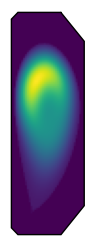

In [460]:
H, W = 120, 40
weights_path = Path("fusion_epochs/fusion_epoch_2193.pth")
assert weights_path.exists(), f"Missing checkpoint: {weights_path}"

num_train_steps = 1000
schedule = build_schedule(num_train_steps=num_train_steps, device=device)

model = MyTinyUNet(in_c=1, out_c=1, n_steps=num_train_steps).to(device)
raw_state = torch.load(weights_path, map_location=device)

if isinstance(raw_state, dict) and "state_dict" in raw_state:
    raw_state = raw_state["state_dict"]

if isinstance(raw_state, dict) and any(k.startswith("network.") for k in raw_state.keys()):
    net_state = {k[len("network."):]: v for k, v in raw_state.items() if k.startswith("network.")}
else:
    net_state = raw_state

missing, unexpected = model.load_state_dict(net_state, strict=False)
print("missing keys:", len(missing))
print("unexpected keys:", len(unexpected))
if missing or unexpected:
    raise RuntimeError("Checkpoint/model mismatch. Check architecture or key prefix handling.")

sample_idx = 35 # 28 : rdd beats diffusion and rd
#122->small ring around center, 2->fine right asymmetry,
# 9->upper left asymm works super well, 12->lower asymm works bad,
# 30->blob centered, 29->big fat ring
# 31 -> bottom asymm works bad, 41-> top asym works well
# 47->left asym works quite well, 49->left asym plasma very high in vessel works well
# 87-> right asym works well
candidate_paths = [
    Path(f"/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy"),
    Path(f"../../data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
    Path(f"data/sxr_data/sxr_profiles_coarse/sxr_sample_{sample_idx}.npy"),
]
x_gt = None
for p in candidate_paths:
    if p.exists():
        x_np = np.load(p)[sample_idx]
        x_gt = torch.from_numpy(x_np).float().to(device).view(1, 1, H, W)
        print(f"Loaded x_gt from: {p}")
        break

tomo_plots.plot_profile(np.array(x_gt.detach().cpu().squeeze()), tcv_plot_clip=True,
                                cmap="viridis", figsize=(1,3))
plt.show()

### diffusion

0.0 1.0 (80, 4800)
A_tomo: (80, 4800)


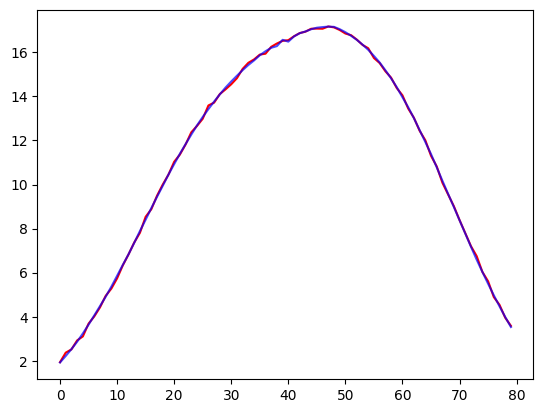

In [461]:
A_path = Path("forward_model/pilatus_geometry_matrix.npy") # sparse_mat_artificial_coarse_random_1e4.npz or sparse_geometry_matrix_sxr.npz or forward_model_sxr_full_geometry.npy
assert A_path.exists(), f"Missing forward matrix: {A_path}"
 
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

A_sparse = np.load(A_path).astype(np.float32)
A_sparse /= A_sparse.max()  # normalize for better conditioning
print(A_sparse.min(), A_sparse.max(), A_sparse.shape)
A_tomo = torch.from_numpy(A_sparse).to(device)
print("A_tomo:", tuple(A_tomo.shape))


sigma_y_tomo = 0.07#1e-1
y_tomo = A_tomo @ x_gt.flatten() + sigma_y_tomo * torch.randn(A_tomo.shape[0], device=device)


plt.plot(y_tomo.cpu().numpy(), label="y_tomo", color='r')
plt.plot((A_tomo @ x_gt.flatten()).cpu().numpy(), label="A @ x_gt", color='b', alpha=0.7)
plt.show()

In [462]:
# select samples to be used for normalization procedure
samples_idxs = np.arange(0,1000)
train_samples_path = Path(f"../../data/sxr_data/sxr_profiles_coarse")
train_samples_normalization = []
for sample_id_ in samples_idxs:
    path = os.path.join(train_samples_path, f"sxr_sample_{sample_id_}.npy")
    train_samples_normalization.append(np.load(path))
train_samples_normalization = torch.from_numpy(np.array(train_samples_normalization, dtype=np.float32)).to(device)

# compute y_tomo distribution
y_tomo_train = train_samples_normalization.reshape(-1, H * W) @ A_tomo.T

In [463]:
print(0.01 * np.mean(y_tomo_train.cpu().numpy()),
      0.05 * np.mean(y_tomo_train.cpu().numpy()),
      0.1 * np.mean(y_tomo_train.cpu().numpy()))

0.06887914 0.34439573 0.68879145


In [464]:
np.mean(y_tomo_train.cpu().numpy())

np.float32(6.8879147)

In [465]:
# # check that procedure will not lead to failure of the diffusion model
# estimated_noises = []
# sp=np.load('scaling_params.npy')
# nrd=np.load('noise_realizations_pilatus.npy')

# for i in range(1000):
#     candidate_paths = [
#     Path(f"/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples/sxr_samples_with_background_coarse.npy"),
#     ]
#     x_gt = None
#     for p in candidate_paths:
#         x_np = np.load(p)[i]
#         x_gt = torch.from_numpy(x_np).float().to(device).view(1, 1, H, W)
#     sigma_y_tomo=0.07
#     y_tomo = A_tomo @ x_gt.flatten() + sigma_y_tomo * torch.from_numpy(nrd[i]).to(device).to(torch.float32)
#     y_tomo *= sp[i]
#     sigma_y_tomo *= sp[i]
#     alpha, _ = compute_normalization_coefficient(y_tomo.reshape(1, -1), y_tomo_train)
#     estimated_noises.append(sigma_y_tomo / alpha)

In [466]:
# plt.plot(estimated_noises)
# print(np.min(estimated_noises))

In [467]:
import scipy.sparse as sp
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp
from pyxu_diffops.operator import AnisDiffusionOp
import skimage.transform as skimt
import os

anis_param = 2e-1

psi = np.load('test_set_sxr_samples/psis_coarse.npy')[sample_idx]

g = AnisDiffusionOp(
    dim_shape=(1, H, W),
    alpha=anis_param,
    diff_method_struct_tens="fd",
    freezing_arr=psi,
    sampling=0.0125,
    matrix_based_impl=True,
)

In [ ]:
psi = np.load('test_set_sxr_samples/psis_coarse.npy')[sample_idx]
samples_dir = Path(f'/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples')
trim_val_ = np.load(os.path.join(samples_dir, 'trimming_values.npy'))[sample_idx, :]
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=(H, W), trim_values_x=trim_val_)

posterior_tomo_no_mask, tomo_residuals_no_mask, diffusion_process_no_mask = sample_posterior_diffpir(
    model=model,
    schedule=schedule,
    A=A_tomo,
    y=y_tomo,
    image_shape=(1, H, W),
    num_samples=100,
    num_inference_steps=250,
    zeta=0.8,
    sigma_y=sigma_y_tomo,
    lambda_=100,  
    clipping_mask=None, #torch.tensor(mask_core, dtype=torch.float32, device=device)
)

posterior_tomo_masked, tomo_residuals_masked, diffusion_process_masked = sample_posterior_diffpir(
    model=model,
    schedule=schedule,
    A=A_tomo,
    y=y_tomo,
    image_shape=(1, H, W),
    num_samples=100,
    num_inference_steps=250,
    zeta=0.8,
    sigma_y=sigma_y_tomo,
    lambda_=100,  
    clipping_mask=torch.tensor(mask_core, dtype=torch.float32, device=device),
)

compute_rdd=True
if compute_rdd:
    posterior_tomo_rdd, tomo_residuals_rdd, diffusion_process_rdd = sample_posterior_diffpir(
        model=model,
        schedule=schedule,
        A=A_tomo,
        y=y_tomo,
        image_shape=(1, H, W),
        num_samples=100,
        num_inference_steps=250,
        zeta=0.9,
        sigma_y=sigma_y_tomo,
        lambda_=10,  
        clipping_mask=torch.tensor(mask_core, dtype=torch.float32, device=device),
        reaction_diffusion_op = g,
        lambda_rd = 1e-6, #1e-4
    )


# posterior_tomo, tomo_residuals, diffusion_process = sample_posterior_dps(
#     model=model,
#     schedule=schedule,
#     A=A_tomo,
#     y=y_tomo,
#     image_shape=(1, H, W),
#     num_samples=100,
#     num_inference_steps=250,
#     eta=0., # 0 for sparse_mat_artificial_coarse_random_1e4
#     sigma_y=sigma_y_tomo,
#     guidance_scale=0.5,  # 0.3 for sparse_mat_artificial_coarse_random_1e4 model
#     clip_range=None,
# )

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

Posterior sampling:   0%|          | 0/250 [00:00<?, ?it/s]

In [477]:
np.logspace(-7, -1, 7)

array([1.e-07, 1.e-06, 1.e-05, 1.e-04, 1.e-03, 1.e-02, 1.e-01])

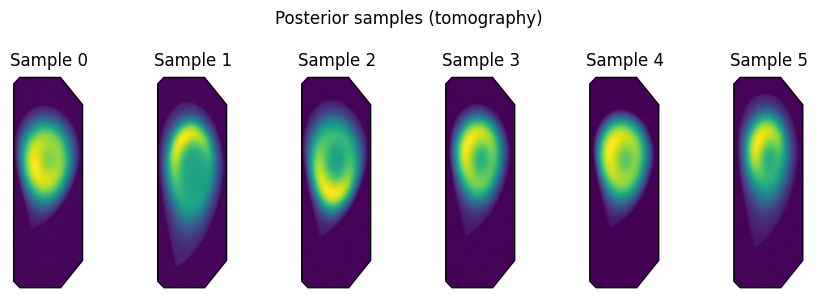

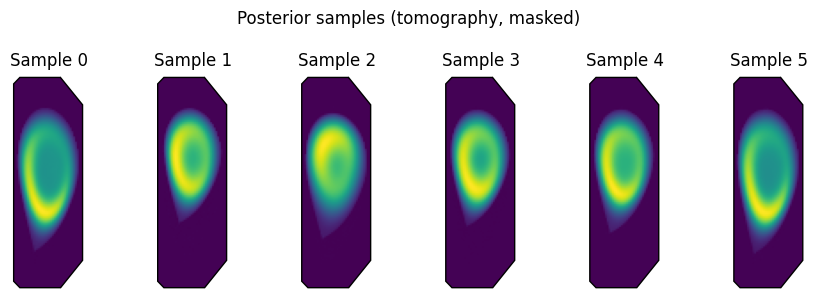

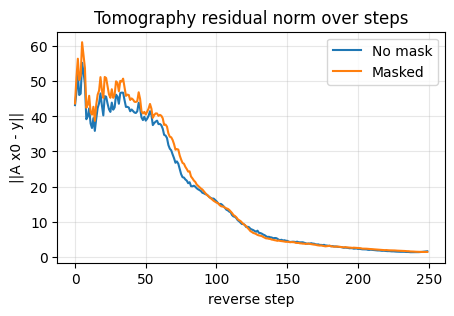

In [469]:
show_samples(posterior_tomo_no_mask[:6], title="Posterior samples (tomography)", ncols=6)
show_samples(posterior_tomo_masked[:6], title="Posterior samples (tomography, masked)", ncols=6)
plt.figure(figsize=(5, 3))
plt.plot(tomo_residuals_no_mask, label="No mask")
plt.plot(tomo_residuals_masked, label="Masked")
plt.title("Tomography residual norm over steps")
plt.xlabel("reverse step")
plt.ylabel("||A x0 - y||")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

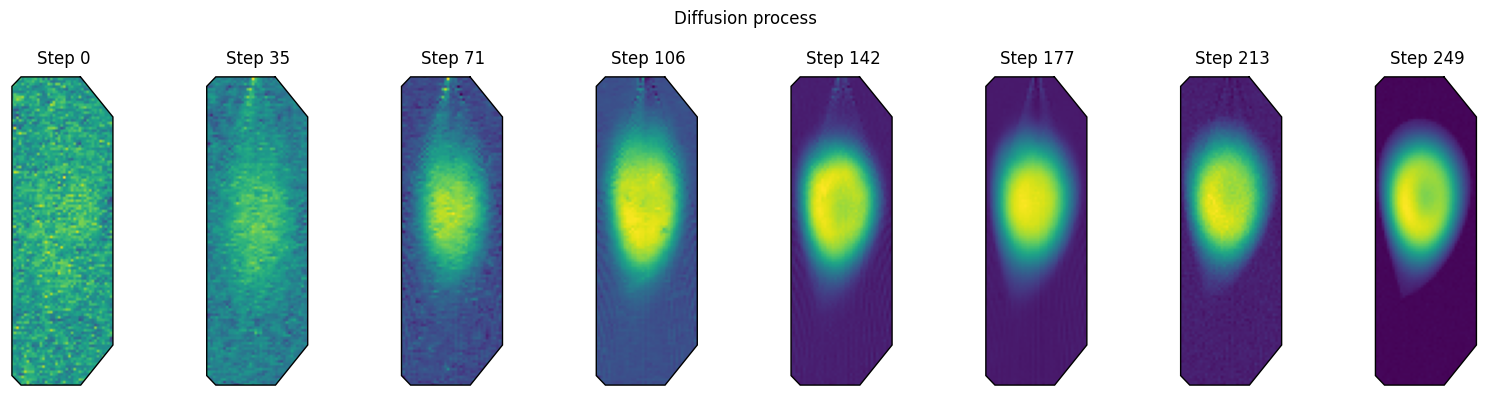

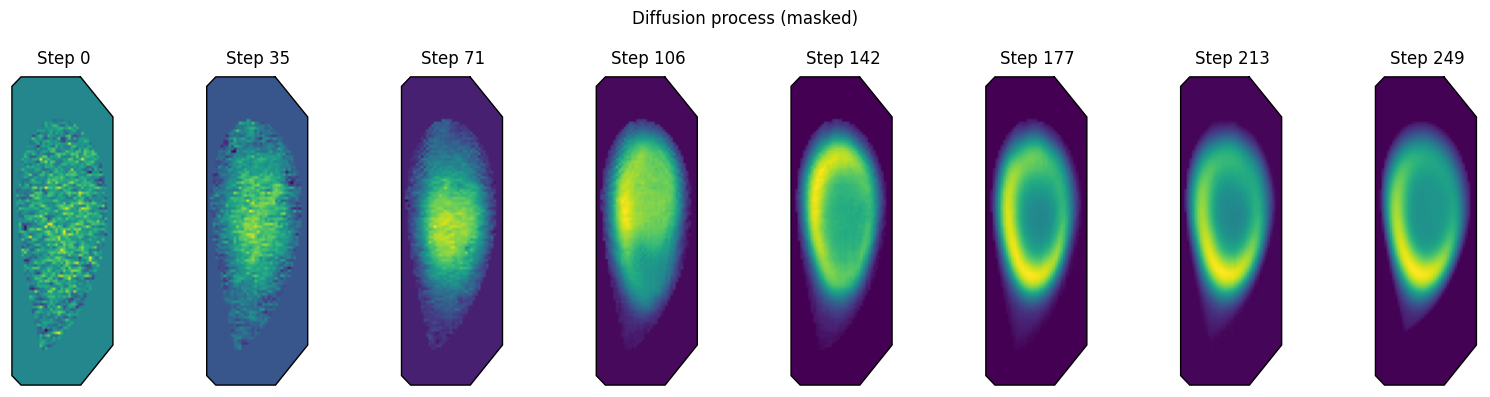

In [470]:
indices = np.linspace(0, len(diffusion_process_no_mask) - 1, 8, dtype=int)
dp_tensor_no_mask = torch.stack([diffusion_process_no_mask[i] for i in indices])
show_samples(
    dp_tensor_no_mask,
    titles=[f"Step {i}" for i in indices],
    ncols=8,
    figsize=(16, 4),
    title="Diffusion process",
)
dp_tensor_masked = torch.stack([diffusion_process_masked[i] for i in indices])
show_samples(
    dp_tensor_masked,
    titles=[f"Step {i}" for i in indices],
    ncols=8,
    figsize=(16, 4),
    title="Diffusion process (masked)",
)

### reaction-diffusion reconstruction

In [471]:
import scipy.sparse as sp
import reaction_diffusion.routines.tomo_fusion.functionals_definition as fct_def
import reaction_diffusion.routines.tomo_fusion.bayesian_computations as bcomp
from pyxu_diffops.operator import AnisDiffusionOp
import skimage.transform as skimt
import os

sigma_err = sigma_y_tomo
anis_param = 2e-1
reg_param = 1e-1
with_positivity_constraint = True

psi = np.load('test_set_sxr_samples/psis_coarse.npy')[sample_idx]
noisy_tomo_data = y_tomo.cpu().numpy().reshape(1, -1)
# scaling_factor = np.max(np.abs(noisy_tomo_data))
# noisy_tomo_data /= scaling_factor  # normalize for better conditioning

f = fct_def._DataFidelityFunctional(
    dim_shape=(1, H, W),
    noisy_tomo_data=noisy_tomo_data,
    sigma_err=sigma_err,
    geometry_matrix=sp.csr_matrix(A_tomo.cpu().numpy()),
)
g = AnisDiffusionOp(
    dim_shape=(1, H, W),
    alpha=anis_param,
    diff_method_struct_tens="fd",
    freezing_arr=psi,
    sampling=0.0125,
    matrix_based_impl=True,
)

tcv_mask = np.load("/home/fusiontomo/Repos/diffusion_tomography/reaction_diffusion/routines/tcv_mask_1_subpixels_NINO.npy")
tcv_mask = skimt.resize(tcv_mask, (120, 40), anti_aliasing=False, mode='edge')
tcv_mask[tcv_mask>0]=1

samples_dir = Path(f'/home/fusiontomo/Repos/diffusion_tomography/test_set_sxr_samples')
trim_val_ = np.load(os.path.join(samples_dir, 'trimming_values.npy'))[sample_idx, :]
mask_core = tomo_helps.define_core_mask(psi=psi, dim_shape=(H, W), trim_values_x=trim_val_)

im_map_masked = bcomp.compute_MAP(
    f, g, reg_param,
    with_pos_constraint=with_positivity_constraint,
    clipping_mask=mask_core,  # mask_core or tcv_mask
    show_progress=True,
) #* scaling_factor  # rescale back to original range

x_map_masked = torch.from_numpy(im_map_masked).float().view(1, 1, H, W)

im_map_no_mask = bcomp.compute_MAP(
    f, g, reg_param,
    with_pos_constraint=with_positivity_constraint,
    clipping_mask=None,  # mask_core or tcv_mask
    show_progress=True,
) #* scaling_factor  # rescale back to original range

x_map_no_mask = torch.from_numpy(im_map_no_mask).float().view(1, 1, H, W)

INFO -- [2026-05-04 15:12:45.099241] Iteration 0
	iteration: 0
	N_iter: 1
	RelError[x]: 0
INFO -- [2026-05-04 15:12:45.544703] Iteration 1_000
	iteration: 1000
	N_iter: 1001
	RelError[x]: 0
INFO -- [2026-05-04 15:12:45.832086] Iteration 1_647
	iteration: 1647
	N_iter: 1648
	RelError[x]: 0
INFO -- [2026-05-04 15:12:45.832739] Stopping Criterion satisfied -> END
INFO -- [2026-05-04 15:12:45.837407] Iteration 0
	iteration: 0
	N_iter: 1
	RelError[x]: 0
INFO -- [2026-05-04 15:12:46.281330] Iteration 1_000
	iteration: 1000
	N_iter: 1001
	RelError[x]: 0
INFO -- [2026-05-04 15:12:46.723220] Iteration 2_000
	iteration: 2000
	N_iter: 2001
	RelError[x]: 0
INFO -- [2026-05-04 15:12:47.165426] Iteration 3_000
	iteration: 3000
	N_iter: 3001
	RelError[x]: 0
INFO -- [2026-05-04 15:12:47.429978] Iteration 3_597
	iteration: 3597
	N_iter: 3598
	RelError[x]: 0
INFO -- [2026-05-04 15:12:47.430776] Stopping Criterion satisfied -> END


In [472]:
g_torch = torch.tensor(g._grad_matrix_based.mat.toarray())
g.diff_lipschitz

102400.0

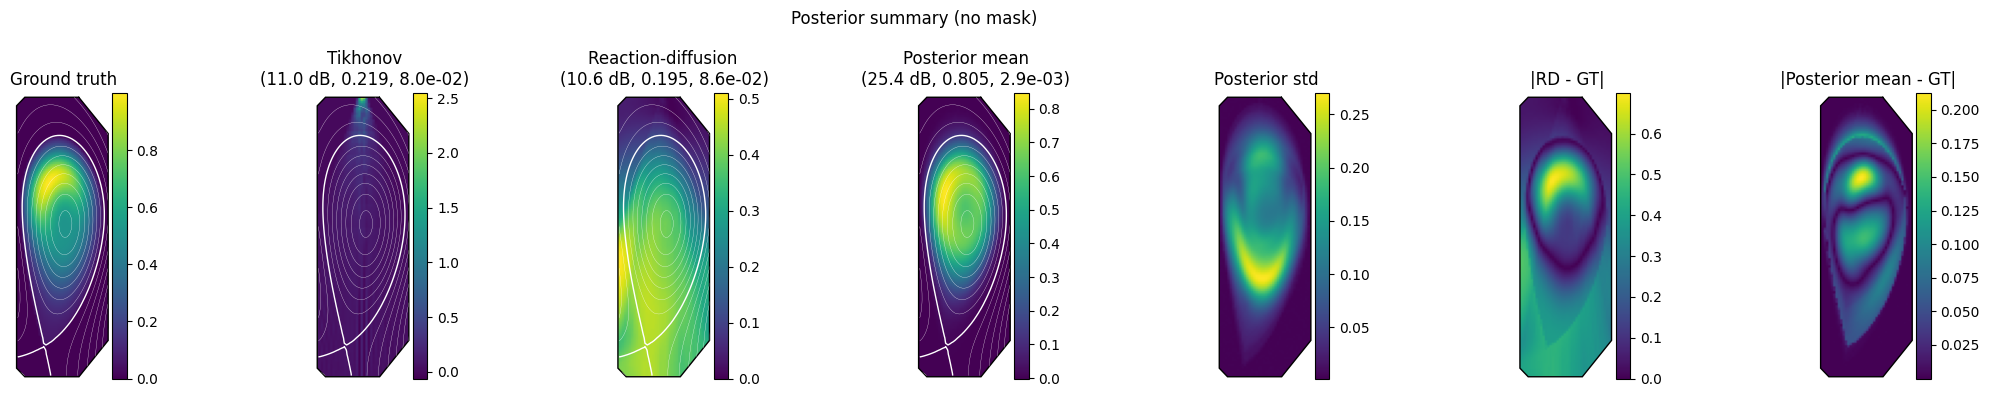

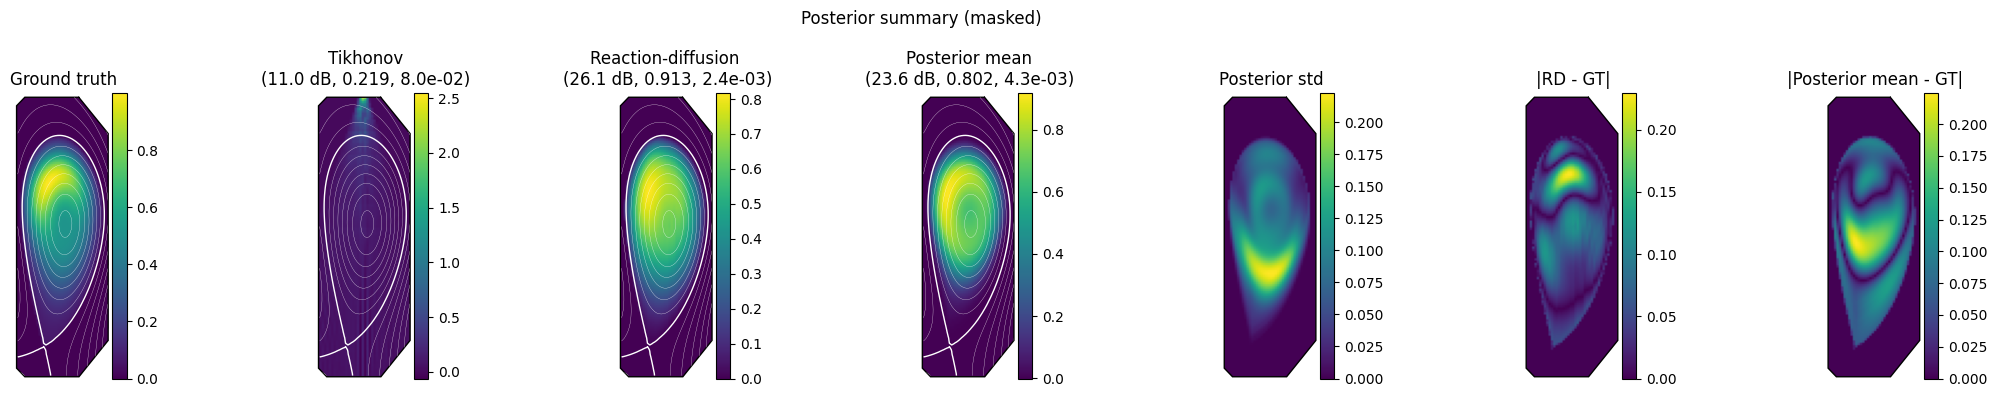

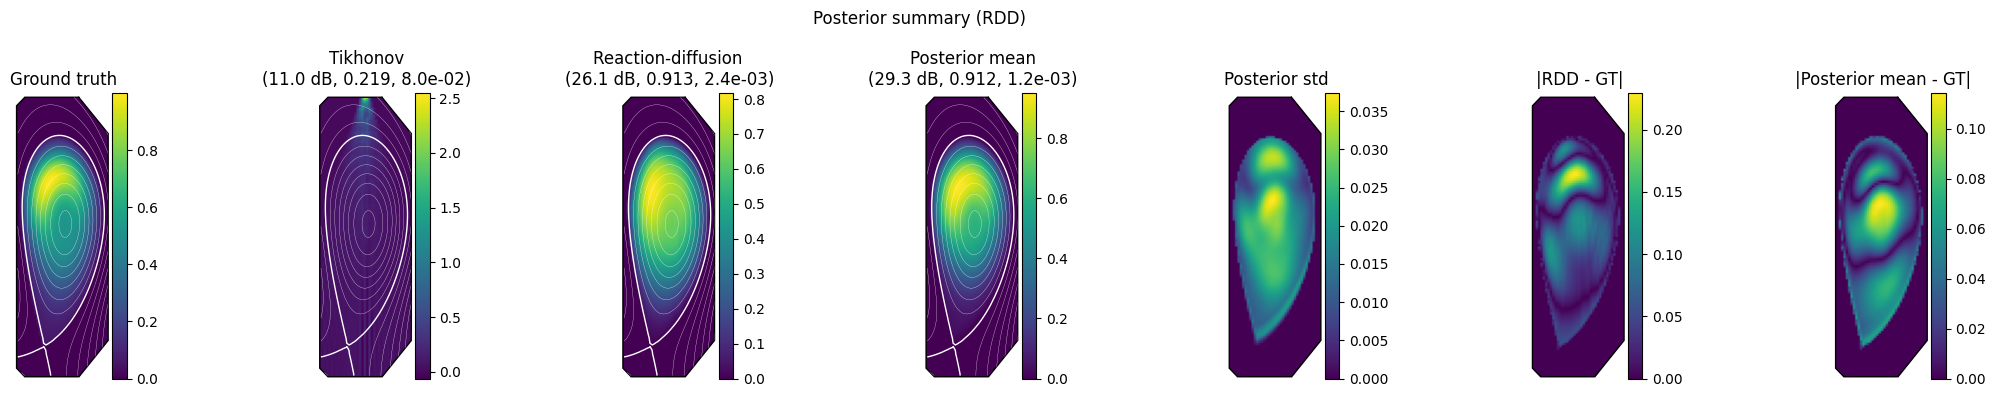

In [473]:
# ------------------------------
#  Posterior summary + baselines
# ------------------------------
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

post_mean_no_mask = posterior_tomo_no_mask.mean(dim=0, keepdim=True)
post_std_no_mask  = posterior_tomo_no_mask.std(dim=0, keepdim=True)
post_mean_masked = posterior_tomo_masked.mean(dim=0, keepdim=True)
post_std_masked  = posterior_tomo_masked.std(dim=0, keepdim=True)
post_mean_rdd = posterior_tomo_rdd.mean(dim=0, keepdim=True)
post_std_rdd  = posterior_tomo_rdd.std(dim=0, keepdim=True)

# Tikhonov baseline (pure physics inversion, no diffusion prior)
lambda_tikh = 1e-1
AtA    = A_tomo.T @ A_tomo
Aty    = A_tomo.T @ y_tomo
x_tikh = torch.linalg.solve(AtA + lambda_tikh * torch.eye(AtA.shape[0], device=device), Aty)
x_tikh = x_tikh.view(1, 1, H, W)

diff_diffpir_no_mask = (post_mean_no_mask - x_gt).abs()
diff_diffpir_masked = (post_mean_masked - x_gt).abs()
diff_diffpir_rdd = (post_mean_rdd - x_gt).abs()
diff_map_no_mask     = (x_map_no_mask.to(device) - x_gt.to(device)).abs()
diff_map_masked      = (x_map_masked.to(device) - x_gt.to(device)).abs()

gt_np = x_gt[0, 0].cpu().numpy()
data_range = gt_np.max() - gt_np.min()

def metrics(recon):
    r = recon[0, 0].cpu().numpy()
    p = psnr(gt_np, r, data_range=data_range)
    s = ssim(gt_np, r, data_range=data_range)
    mse = np.mean((gt_np - r) ** 2)
    return f"({p:.1f} dB, {s:.3f}, {mse:.1e})"

summary_no_mask = torch.stack([
    x_gt[0, 0].cpu(),
    x_tikh[0, 0].cpu(),
    x_map_no_mask[0, 0].cpu(),
    post_mean_no_mask[0, 0].cpu(),
    post_std_no_mask[0, 0].cpu(),
    diff_map_no_mask[0, 0].cpu(),
    diff_diffpir_no_mask[0, 0].cpu(),
])

summary_masked = torch.stack([
    x_gt[0, 0].cpu(),
    x_tikh[0, 0].cpu(),
    x_map_masked[0, 0].cpu(),
    post_mean_masked[0, 0].cpu(),
    post_std_masked[0, 0].cpu(),
    diff_map_masked[0, 0].cpu(),
    diff_diffpir_masked[0, 0].cpu(),
])

summary_rdd = torch.stack([
    x_gt[0, 0].cpu(),
    x_tikh[0, 0].cpu(),
    x_map_masked[0, 0].cpu(),
    post_mean_rdd[0, 0].cpu(),
    post_std_rdd[0, 0].cpu(),
    diff_map_masked[0, 0].cpu(),
    diff_diffpir_rdd[0, 0].cpu(),
])
show_samples(
    summary_no_mask,
    title="Posterior summary (no mask)",
    titles=[
        "Ground truth",
        f"Tikhonov\n{metrics(x_tikh)}",
        f"Reaction-diffusion \n{metrics(x_map_no_mask.to(device))}",
        f"Posterior mean\n{metrics(post_mean_no_mask.to(device))}",
        "Posterior std",
        "|RD - GT|",
        "|Posterior mean - GT|",
    ],
    ncols=7,
    figsize=(22, 4),
    contour_images=[psi, psi, psi, psi, None, None, None],
    colorbar=True,
)

show_samples(
    summary_masked,
    title="Posterior summary (masked)",
    titles=[
        "Ground truth",
        f"Tikhonov\n{metrics(x_tikh)}",
        f"Reaction-diffusion \n{metrics(x_map_masked.to(device))}",
        f"Posterior mean\n{metrics(post_mean_masked.to(device))}",
        "Posterior std",
        "|RD - GT|",
        "|Posterior mean - GT|",
    ],
    ncols=7,
    figsize=(22, 4),
    contour_images=[psi, psi, psi, psi, None, None, None],
    colorbar=True,
)
show_samples(
    summary_rdd,
    title="Posterior summary (RDD)",
    titles=[
        "Ground truth",
        f"Tikhonov\n{metrics(x_tikh)}",
        f"Reaction-diffusion \n{metrics(x_map_masked.to(device))}",
        f"Posterior mean\n{metrics(post_mean_rdd.to(device))}",
        "Posterior std",
        "|RDD - GT|",
        "|Posterior mean - GT|",
    ],
    ncols=7,
    figsize=(22, 4),
    contour_images=[psi, psi, psi, psi, None, None, None],
    colorbar=True,
)

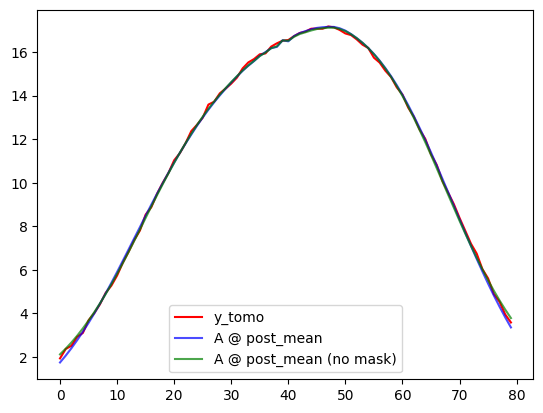

In [474]:
plt.plot(y_tomo.cpu().numpy(), label="y_tomo", color='r')
plt.plot((A_tomo @ post_mean_masked[0, 0].flatten()).cpu().numpy(), label="A @ post_mean", color='b', alpha=0.7)
plt.plot((A_tomo @ post_mean_no_mask[0, 0].flatten()).cpu().numpy(), label="A @ post_mean (no mask)", color='g', alpha=0.7)
plt.legend()
plt.show()

In [475]:
31dB

SyntaxError: invalid decimal literal (2887408340.py, line 1)